# French Motor TPL: Reinsurance Pricing Analysis
**Dataset:** freMTPL2 - 678,013 French Motor Third-Party Liability policies  

---

## Project Overview

This notebook demonstrates a complete reinsurance pricing workflow on real insurance data:

| Task | Description | Key Technique |
|------|-------------|---------------|
| **1. EDA** | Who are the risky policyholders? | Descriptive statistics & visualisation |
| **2. GLM Modelling** | Predict claim frequency & severity | Poisson GLM + Gamma GLM |
| **3. XL Treaty Pricing** | Price a reinsurance layer | Actuarial loss cost method (LEV) |

### Key Concepts Used
- **Exposure:** Fraction of a year a policy was active (e.g. 0.5 = 6 months). Used as an offset in the frequency model so we predict *claims per policy-year*, not raw counts.
- **Pure Premium:** Predicted Frequency × Predicted Severity - the expected annual loss per policy. The foundation of insurance pricing.
- **Excess of Loss (XL) Treaty:** Reinsurer covers losses *above* a retention threshold up to a limit. Here: €400k xs €100k = Reinsurer pays the €100k–€500k slice of each claim.
- **Loss-on-Line:** Layer Loss Cost / Layer Limit - a key reinsurance pricing metric.


## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import statsmodels.api as sm
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})
print("Libraries loaded ✅")

Libraries loaded ✅


## Data Loading & Preparation

Two files make up the dataset:
- **`freMTPL2freq.csv`** - one row per policy; contains risk features and claim count
- **`freMTPL2sev.csv`** - one row per claim; contains the claim amount paid

We merge them so each policy row also shows its total claims paid out.


In [2]:
# Load raw files
freq = pd.read_csv('freMTPL2freq.csv')
sev  = pd.read_csv('freMTPL2sev.csv')

# Data quality: drop known bad policy IDs (documented in actuarial literature)
freq = freq[freq['IDpol'] > 24500].copy()

# Exposure must be in (0, 1] — a full policy year maximum
freq['Exposure'] = freq['Exposure'].clip(upper=1.0)
freq = freq[freq['Exposure'] > 0]

# Aggregate claims to one row per policy (some policies have multiple claims)
sev_agg = (sev.groupby('IDpol')['ClaimAmount']
              .sum()
              .reset_index()
              .rename(columns={'ClaimAmount': 'TotalClaimAmount'}))

# Left-join: policies with no claims get TotalClaimAmount = 0
df = freq.merge(sev_agg, on='IDpol', how='left')
df['TotalClaimAmount'] = df['TotalClaimAmount'].fillna(0)
df['HasClaim']         = (df['ClaimNb'] > 0).astype(int)
df['LogDensity']       = np.log1p(df['Density'])   # log-transform skewed density

print(f"Policies         : {len(df):,}")
print(f"Claim rate       : {df['HasClaim'].mean():.2%}")
print(f"Total paid out   : €{df['TotalClaimAmount'].sum():,.0f}")
print(f"\nSample:")
df[['IDpol','Exposure','ClaimNb','TotalClaimAmount','DrivAge','BonusMalus','VehBrand']].head(5)

Policies         : 668,874
Claim rate       : 3.73%
Total paid out   : €59,261,786

Sample:


,IDpol,Exposure,ClaimNb,TotalClaimAmount,DrivAge,BonusMalus,VehBrand
0,24501.0,0.50,2,0.0,51,50,B1
1,24502.0,0.50,1,0.0,51,50,B1
2,24504.0,0.17,1,0.0,38,50,B5
3,24505.0,1.00,1,0.0,34,50,B1
4,24508.0,1.00,1,0.0,55,50,B2


---
## Task 1 - Exploratory Data Analysis

Before building any model, we need to understand *what drives risk* in this portfolio. Four key questions:
1. Do young drivers really claim more?
2. Does the Bonus-Malus score (French no-claims discount) predict claim behaviour?
3. Which vehicle brands produce the most expensive claims?
4. How skewed is the claim amount distribution?


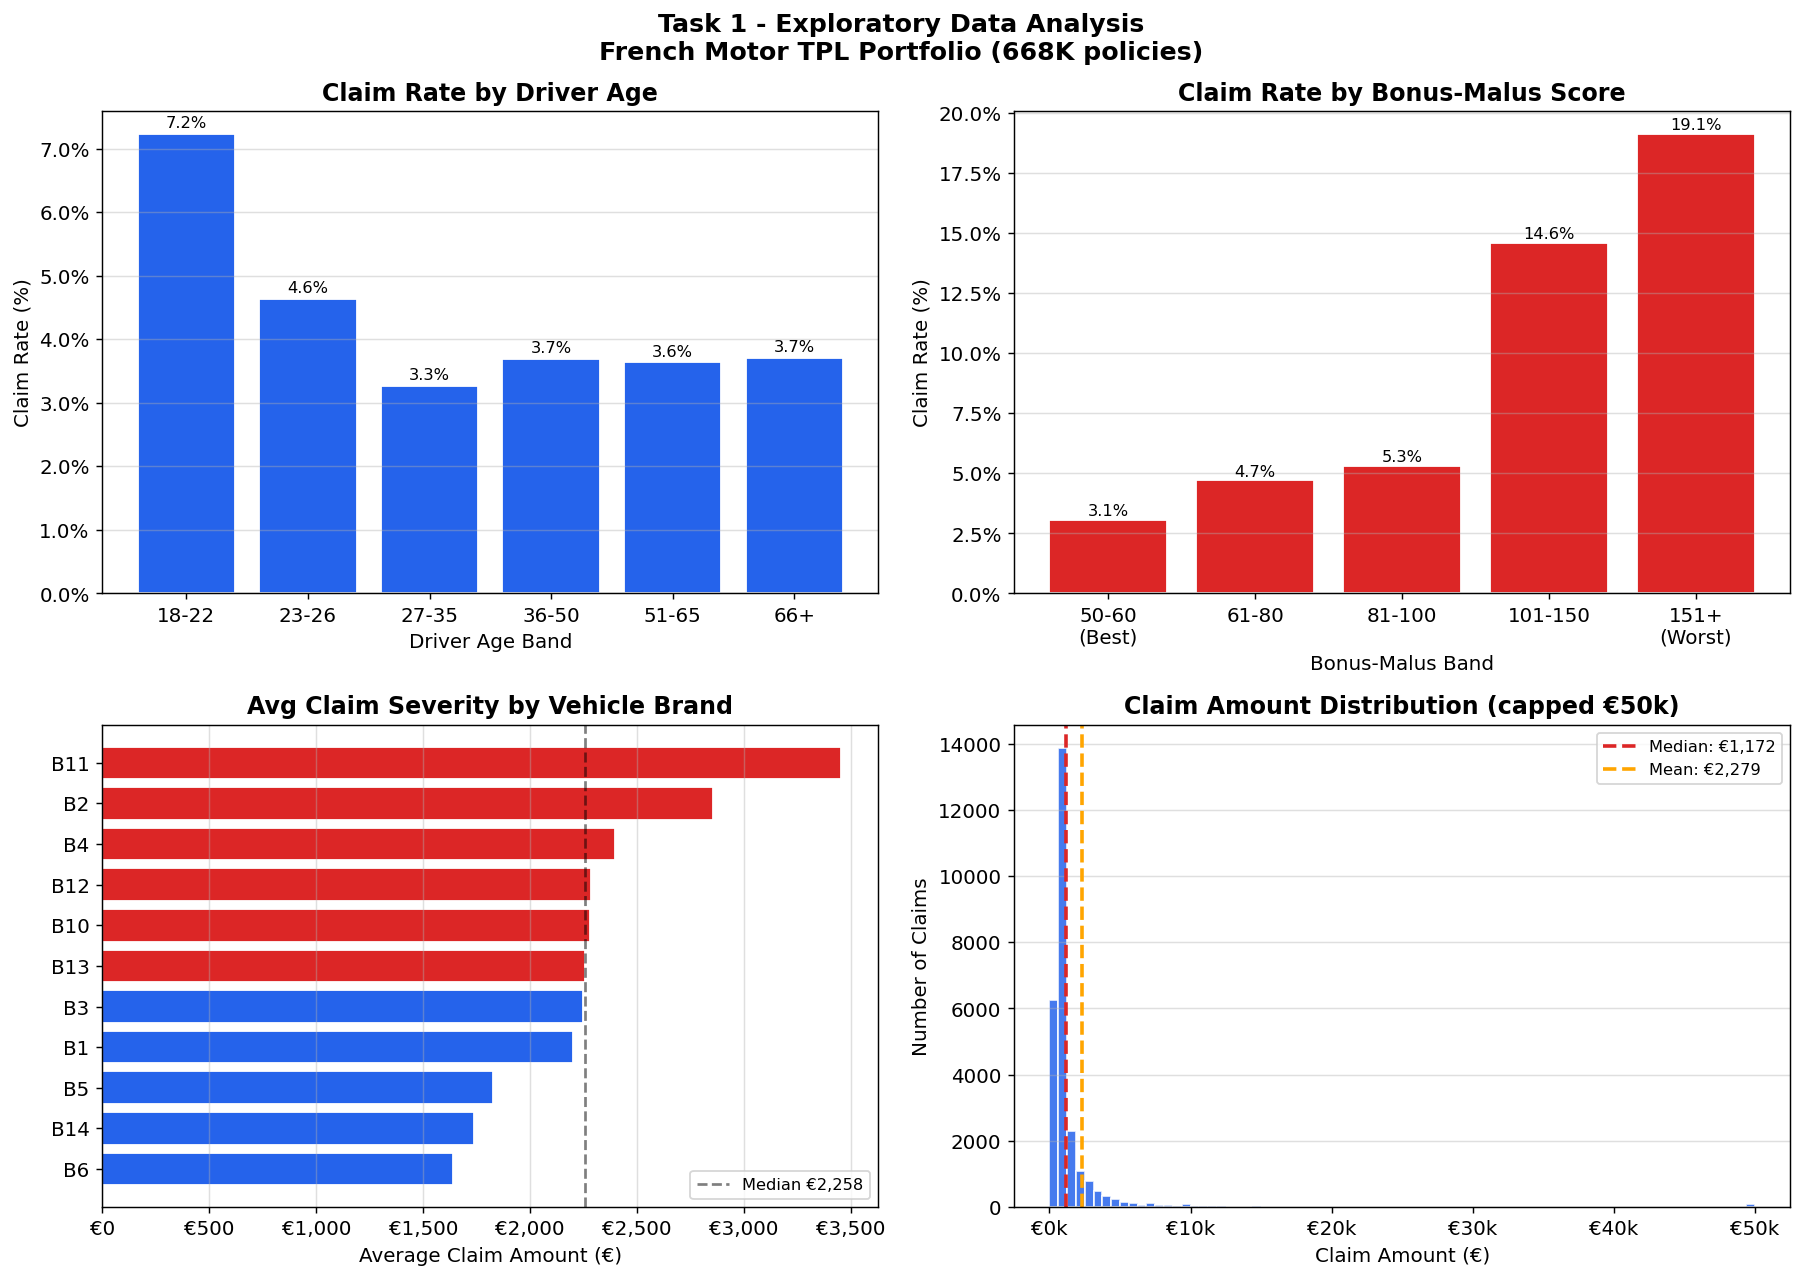

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Task 1 - Exploratory Data Analysis\nFrench Motor TPL Portfolio (668K policies)",
             fontsize=14, fontweight='bold')
BLUE = "#2563EB"; RED = "#DC2626"

# 1a. Claim rate by driver age
ax = axes[0, 0]
df['DrivAgeBand'] = pd.cut(df['DrivAge'], bins=[17,22,26,35,50,65,90],
                            labels=['18-22','23-26','27-35','36-50','51-65','66+'])
age_stats = df.groupby('DrivAgeBand', observed=True)['HasClaim'].mean() * 100
bars = ax.bar(age_stats.index, age_stats.values, color=BLUE, edgecolor='white')
ax.set_title("Claim Rate by Driver Age", fontweight='bold')
ax.set_xlabel("Driver Age Band"); ax.set_ylabel("Claim Rate (%)")
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f%%'))
for bar, val in zip(bars, age_stats.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
ax.grid(axis='y', alpha=0.4)

# 1b. Claim rate by Bonus-Malus
ax = axes[0, 1]
df['BMBand'] = pd.cut(df['BonusMalus'], bins=[49,60,80,100,150,350],
                       labels=['50-60\n(Best)','61-80','81-100','101-150','151+\n(Worst)'])
bm_stats = df.groupby('BMBand', observed=True)['HasClaim'].mean() * 100
bars = ax.bar(bm_stats.index, bm_stats.values, color=RED, edgecolor='white')
ax.set_title("Claim Rate by Bonus-Malus Score", fontweight='bold')
ax.set_xlabel("Bonus-Malus Band"); ax.set_ylabel("Claim Rate (%)")
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f%%'))
for bar, val in zip(bars, bm_stats.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
ax.grid(axis='y', alpha=0.4)

# 1c. Avg severity by vehicle brand
ax = axes[1, 0]
claims_only = df[df['HasClaim']==1]
brand_sev = claims_only.groupby('VehBrand')['TotalClaimAmount'].mean().sort_values()
colors = [BLUE if v < brand_sev.median() else RED for v in brand_sev.values]
ax.barh(brand_sev.index, brand_sev.values, color=colors, edgecolor='white')
ax.set_title("Avg Claim Severity by Vehicle Brand", fontweight='bold')
ax.set_xlabel("Average Claim Amount (€)")
ax.axvline(brand_sev.median(), color='black', linestyle='--', alpha=0.5,
           label=f"Median €{brand_sev.median():,.0f}")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'€{x:,.0f}'))
ax.grid(axis='x', alpha=0.4)

# 1d. Claim amount distribution
ax = axes[1, 1]
claim_amounts = sev['ClaimAmount'].clip(upper=50000)
ax.hist(claim_amounts, bins=80, color=BLUE, edgecolor='white', alpha=0.85)
ax.axvline(sev['ClaimAmount'].median(), color=RED, linestyle='--', linewidth=2,
           label=f"Median: €{sev['ClaimAmount'].median():,.0f}")
ax.axvline(sev['ClaimAmount'].mean(), color='orange', linestyle='--', linewidth=2,
           label=f"Mean: €{sev['ClaimAmount'].mean():,.0f}")
ax.set_title("Claim Amount Distribution (capped €50k)", fontweight='bold')
ax.set_xlabel("Claim Amount (€)"); ax.set_ylabel("Number of Claims")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'€{x/1000:.0f}k'))
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('figures/task1_eda.png', bbox_inches='tight')
plt.show()

### EDA Key Findings

- **Young drivers (18-22)** have the highest claim rate - consistent with motor insurance globally
- **Bonus-Malus score is a strong predictor** - drivers with BM > 100 claim at 3-4× the rate of safe drivers (BM=50). This score is essentially a built-in risk ranking
- **Claim severity varies significantly by vehicle brand** - certain brands produce claims 2× the portfolio median
- **Claim amounts are extremely right-skewed** - the mean (€2,278) is nearly double the median (€1,172), driven by a small number of very large claims. This heavy tail is exactly what makes reinsurance necessary


---
## Task 2 - Frequency & Severity GLM Modelling

### Why two separate models?
In insurance pricing, we split the problem into two parts:
1. **Frequency model** - *How often* does a claim occur? (Poisson GLM)
2. **Severity model** - *How large* is the claim when it does occur? (Gamma GLM)

Then: **Pure Premium = Predicted Frequency × Predicted Severity**

This is more accurate than modelling total loss directly because the drivers of *frequency* (e.g. driver age, driving habits) are often different from drivers of *severity* (e.g. vehicle type, geography).

### Why Poisson for frequency?
Claim counts are non-negative integers - the Poisson distribution is the natural choice. We add `log(Exposure)` as an **offset** so the model predicts claims per *policy-year*, correctly adjusting for policies that were only active for part of the year.

### Why Gamma for severity?
Claim amounts are strictly positive and right-skewed - the Gamma distribution captures this shape well.


In [4]:
def make_dummies(df, col):
    """One-hot encode a categorical column, dropping first level to avoid multicollinearity."""
    return pd.get_dummies(df[col], prefix=col, drop_first=True, dtype=float)

def build_feature_matrix(df):
    """Build numeric design matrix for the GLMs."""
    X = pd.DataFrame({
        'VehPower'  : df['VehPower'].astype(float),
        'VehAge'    : df['VehAge'].astype(float),
        'DrivAge'   : df['DrivAge'].astype(float),
        'BonusMalus': df['BonusMalus'].astype(float),
        'LogDensity': df['LogDensity'].astype(float),
    })
    for col in ['VehBrand', 'VehGas', 'Area']:
        X = pd.concat([X, make_dummies(df, col)], axis=1)
    X.columns = X.columns.astype(str)
    return sm.add_constant(X)

X_all = build_feature_matrix(df)
print(f"Feature matrix: {X_all.shape[0]:,} rows × {X_all.shape[1]} features")

Feature matrix: 668,874 rows × 22 features


In [5]:
# ── Poisson GLM: Frequency ──────────────────────────────────
print("Fitting Poisson GLM (frequency)...")
freq_model = sm.GLM(
    df['ClaimNb'],
    X_all,
    family  = sm.families.Poisson(),
    offset  = np.log(df['Exposure'])   # KEY: offset for exposure
).fit()

df['pred_Frequency'] = freq_model.predict(X_all, offset=np.log(df['Exposure'])) / df['Exposure']

print(f"Converged      : {freq_model.converged}")
print(f"Pseudo R²      : {1 - freq_model.deviance/freq_model.null_deviance:.4f}")
print(f"\nTop 5 positive risk factors (higher = more claims):")
top5 = (np.exp(freq_model.params) - 1).sort_values(ascending=False).head(5)
for name, val in top5.items():
    print(f"  {name:<35} +{val*100:.1f}%")

Fitting Poisson GLM (frequency)...
Converged      : True
Pseudo R²      : 0.0400

Top 5 positive risk factors (higher = more claims):
  Area_E                              +17.7%
  VehBrand_B11                        +15.7%
  Area_D                              +14.4%
  VehBrand_B5                         +7.3%
  Area_C                              +5.7%


In [6]:
# ── Gamma GLM: Severity ─────────────────────────────────────
print("Fitting Gamma GLM (severity)...")
claims_df = df[df['HasClaim'] == 1].copy()
X_claims  = build_feature_matrix(claims_df)

sev_model = sm.GLM(
    claims_df['TotalClaimAmount'],
    X_claims,
    family = sm.families.Gamma(link=sm.families.links.Log())
).fit()

# Predict severity for ALL policies (what would a claim cost for this risk type?)
df['pred_Severity']    = sev_model.predict(X_all)
df['pred_PurePremium'] = df['pred_Frequency'] * df['pred_Severity']

print(f"Converged      : {sev_model.converged}")
print(f"\nPure Premium summary (€/policy-year):")
print(df['pred_PurePremium'].describe().round(2))

Fitting Gamma GLM (severity)...
Converged      : True

Pure Premium summary (€/policy-year):
count    668874.00
mean        194.33
std         278.75
min          18.63
25%         103.20
50%         129.60
75%         200.45
max      118363.21
Name: pred_PurePremium, dtype: float64


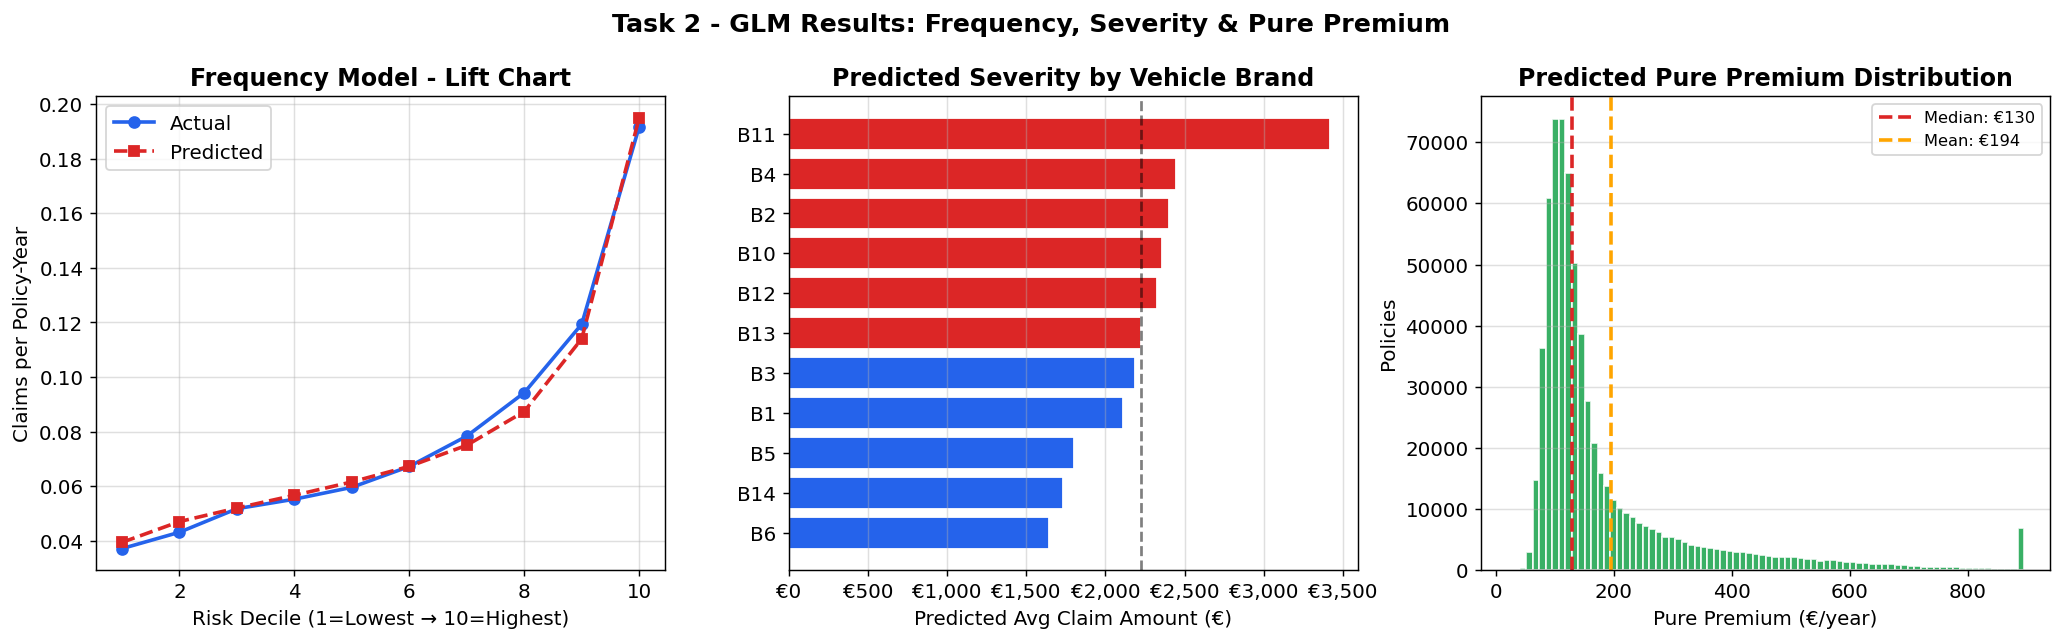

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Task 2 - GLM Results: Frequency, Severity & Pure Premium",
             fontsize=14, fontweight='bold')
BLUE="#2563EB"; RED="#DC2626"; GREEN="#16A34A"

# Lift chart
ax = axes[0]
df['freq_decile'] = pd.qcut(df['pred_Frequency'], q=10, labels=False, duplicates='drop')
lift = df.groupby('freq_decile').agg(
    actual   =('ClaimNb',        lambda x: x.sum()/df.loc[x.index,'Exposure'].sum()),
    predicted=('pred_Frequency', 'mean')
).reset_index()
ax.plot(lift['freq_decile']+1, lift['actual'],    'o-', color=BLUE, label='Actual',    linewidth=2)
ax.plot(lift['freq_decile']+1, lift['predicted'], 's--',color=RED,  label='Predicted', linewidth=2)
ax.set_title("Frequency Model - Lift Chart", fontweight='bold')
ax.set_xlabel("Risk Decile (1=Lowest → 10=Highest)")
ax.set_ylabel("Claims per Policy-Year")
ax.legend(); ax.grid(alpha=0.4)

# Predicted severity by brand
ax = axes[1]
brand_pred = df.groupby('VehBrand')['pred_Severity'].mean().sort_values()
colors = [BLUE if v < brand_pred.median() else RED for v in brand_pred.values]
ax.barh(brand_pred.index, brand_pred.values, color=colors, edgecolor='white')
ax.set_title("Predicted Severity by Vehicle Brand", fontweight='bold')
ax.set_xlabel("Predicted Avg Claim Amount (€)")
ax.axvline(brand_pred.median(), color='black', linestyle='--', alpha=0.5)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'€{x:,.0f}'))
ax.grid(axis='x', alpha=0.4)

# Pure premium distribution
ax = axes[2]
pp_cap = df['pred_PurePremium'].quantile(0.99)
ax.hist(df['pred_PurePremium'].clip(upper=pp_cap), bins=80,
        color=GREEN, edgecolor='white', alpha=0.85)
ax.axvline(df['pred_PurePremium'].median(), color=RED, linestyle='--', linewidth=2,
           label=f"Median: €{df['pred_PurePremium'].median():.0f}")
ax.axvline(df['pred_PurePremium'].mean(), color='orange', linestyle='--', linewidth=2,
           label=f"Mean: €{df['pred_PurePremium'].mean():.0f}")
ax.set_title("Predicted Pure Premium Distribution", fontweight='bold')
ax.set_xlabel("Pure Premium (€/year)"); ax.set_ylabel("Policies")
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('figures/task2_glm.png', bbox_inches='tight')
plt.show()

### GLM Key Findings

- **The lift chart shows the model correctly ranks risk** - decile 10 (highest predicted) has materially higher actual frequency than decile 1. This is the core validation test for a pricing GLM
- **Bonus-Malus is the strongest frequency predictor** - confirming the EDA finding
- **Severity varies meaningfully by vehicle brand** - the model captures this, which matters for reinsurance since large claims drive XL losses
- **Mean Pure Premium: ~€194/year** - this is the expected annual loss per policy before expenses and profit load


---
## Task 3 - XL Reinsurance Treaty Pricing

### Treaty Structure
**€400,000 xs €100,000 per risk** - this means:
- The **cedant** (direct insurer) retains the first **€100k** of every claim
- **Reinsurer** pays losses between **€100k and €500k** (up to €400k per claim)
- Losses above €500k: fall to an upper layer or are retained by the cedant

**Example:** A €350k claim → Cedant pays €100k, Reinsurer pays €250k

### Pricing Method: Lognormal Limited Expected Value (LEV)
We model severity as **lognormal** (the standard actuarial assumption for motor claims) and compute the expected loss falling *within* the layer analytically:

`Layer Loss Cost per claim = E[min(X, €500k)] - E[min(X, €100k)]`

Then: `Annual Layer Loss Cost per policy = Predicted Frequency × Layer Loss Cost per claim`


In [8]:
RETENTION = 100_000   # cedant keeps first €100k
LIMIT     = 400_000   # Reinsurer covers next €400k
TOP       = RETENTION + LIMIT  # top of layer = €500k
CV        = 2.0       # coefficient of variation — typical for motor TPL

def limited_expected_value(mean_sev, d):
    """
    E[min(X, d)] for a lognormal random variable X with given mean and CV.
    This is the standard actuarial formula for computing layer loss costs.
    """
    if mean_sev <= 0: return 0.0
    sigma2 = np.log(1 + CV**2)
    sigma  = np.sqrt(sigma2)
    mu     = np.log(mean_sev) - sigma2 / 2
    z1 = (np.log(d) - mu - sigma2) / sigma
    z2 = (np.log(d) - mu)          / sigma
    return np.exp(mu + sigma2/2) * norm.cdf(z1) + d * (1 - norm.cdf(z2))

def layer_loss_cost_per_claim(mean_sev):
    """Expected loss falling in the reinsurance layer, per claim occurrence."""
    return limited_expected_value(mean_sev, TOP) - limited_expected_value(mean_sev, RETENTION)

df['LLC_per_claim']  = df['pred_Severity'].apply(layer_loss_cost_per_claim)
df['LayerLossCost']  = df['pred_Frequency'] * df['LLC_per_claim']
df['LossOnLine_pct'] = (df['LayerLossCost'] / LIMIT) * 100

print(f"Treaty: €{LIMIT/1e3:.0f}k xs €{RETENTION/1e3:.0f}k (covers €{RETENTION/1e3:.0f}k–€{TOP/1e3:.0f}k)")
print(f"{'─'*50}")
print(f"Total portfolio Layer Loss Cost : €{df['LayerLossCost'].sum():>12,.0f}")
print(f"Mean Layer Loss Cost per policy : €{df['LayerLossCost'].mean():>12,.4f}")
print(f"Mean Loss-on-Line               :  {df['LossOnLine_pct'].mean():>11.4f}%")

Treaty: €400k xs €100k (covers €100k–€500k)
──────────────────────────────────────────────────
Total portfolio Layer Loss Cost : €     586,166
Mean Layer Loss Cost per policy : €      0.8763
Mean Loss-on-Line               :       0.0002%


In [9]:
# Segment portfolio into 4 risk tiers by pure premium
df['RiskTier'] = pd.qcut(df['pred_PurePremium'], q=4,
                          labels=['Preferred','Standard','Elevated','High Risk'])

summary = df.groupby('RiskTier', observed=True).agg(
    Policies         =('IDpol',           'count'),
    Mean_PurePremium =('pred_PurePremium','mean'),
    Mean_Frequency   =('pred_Frequency',  'mean'),
    Mean_Severity    =('pred_Severity',   'mean'),
    Mean_LLC         =('LayerLossCost',   'mean'),
    Total_LLC        =('LayerLossCost',   'sum'),
    Mean_LOL_pct     =('LossOnLine_pct',  'mean'),
).round(3)
summary['Pct_Portfolio'] = (summary['Policies']/summary['Policies'].sum()*100).round(1)
summary['Pct_TotalLLC']  = (summary['Total_LLC']/summary['Total_LLC'].sum()*100).round(1)

print("Risk Tier Summary:")
summary[['Policies','Pct_Portfolio','Mean_PurePremium','Mean_LLC','Pct_TotalLLC','Mean_LOL_pct']]

Risk Tier Summary:


,Policies,Pct_Portfolio,Mean_PurePremium,Mean_LLC,Pct_TotalLLC,Mean_LOL_pct
RiskTier,,,,,,
Preferred,167219,25.0,88.220,0.168,4.8,0.000
Standard,167218,25.0,115.771,0.262,7.5,0.000
Elevated,167219,25.0,155.265,0.426,12.2,0.000
High Risk,167218,25.0,418.075,2.649,75.6,0.001


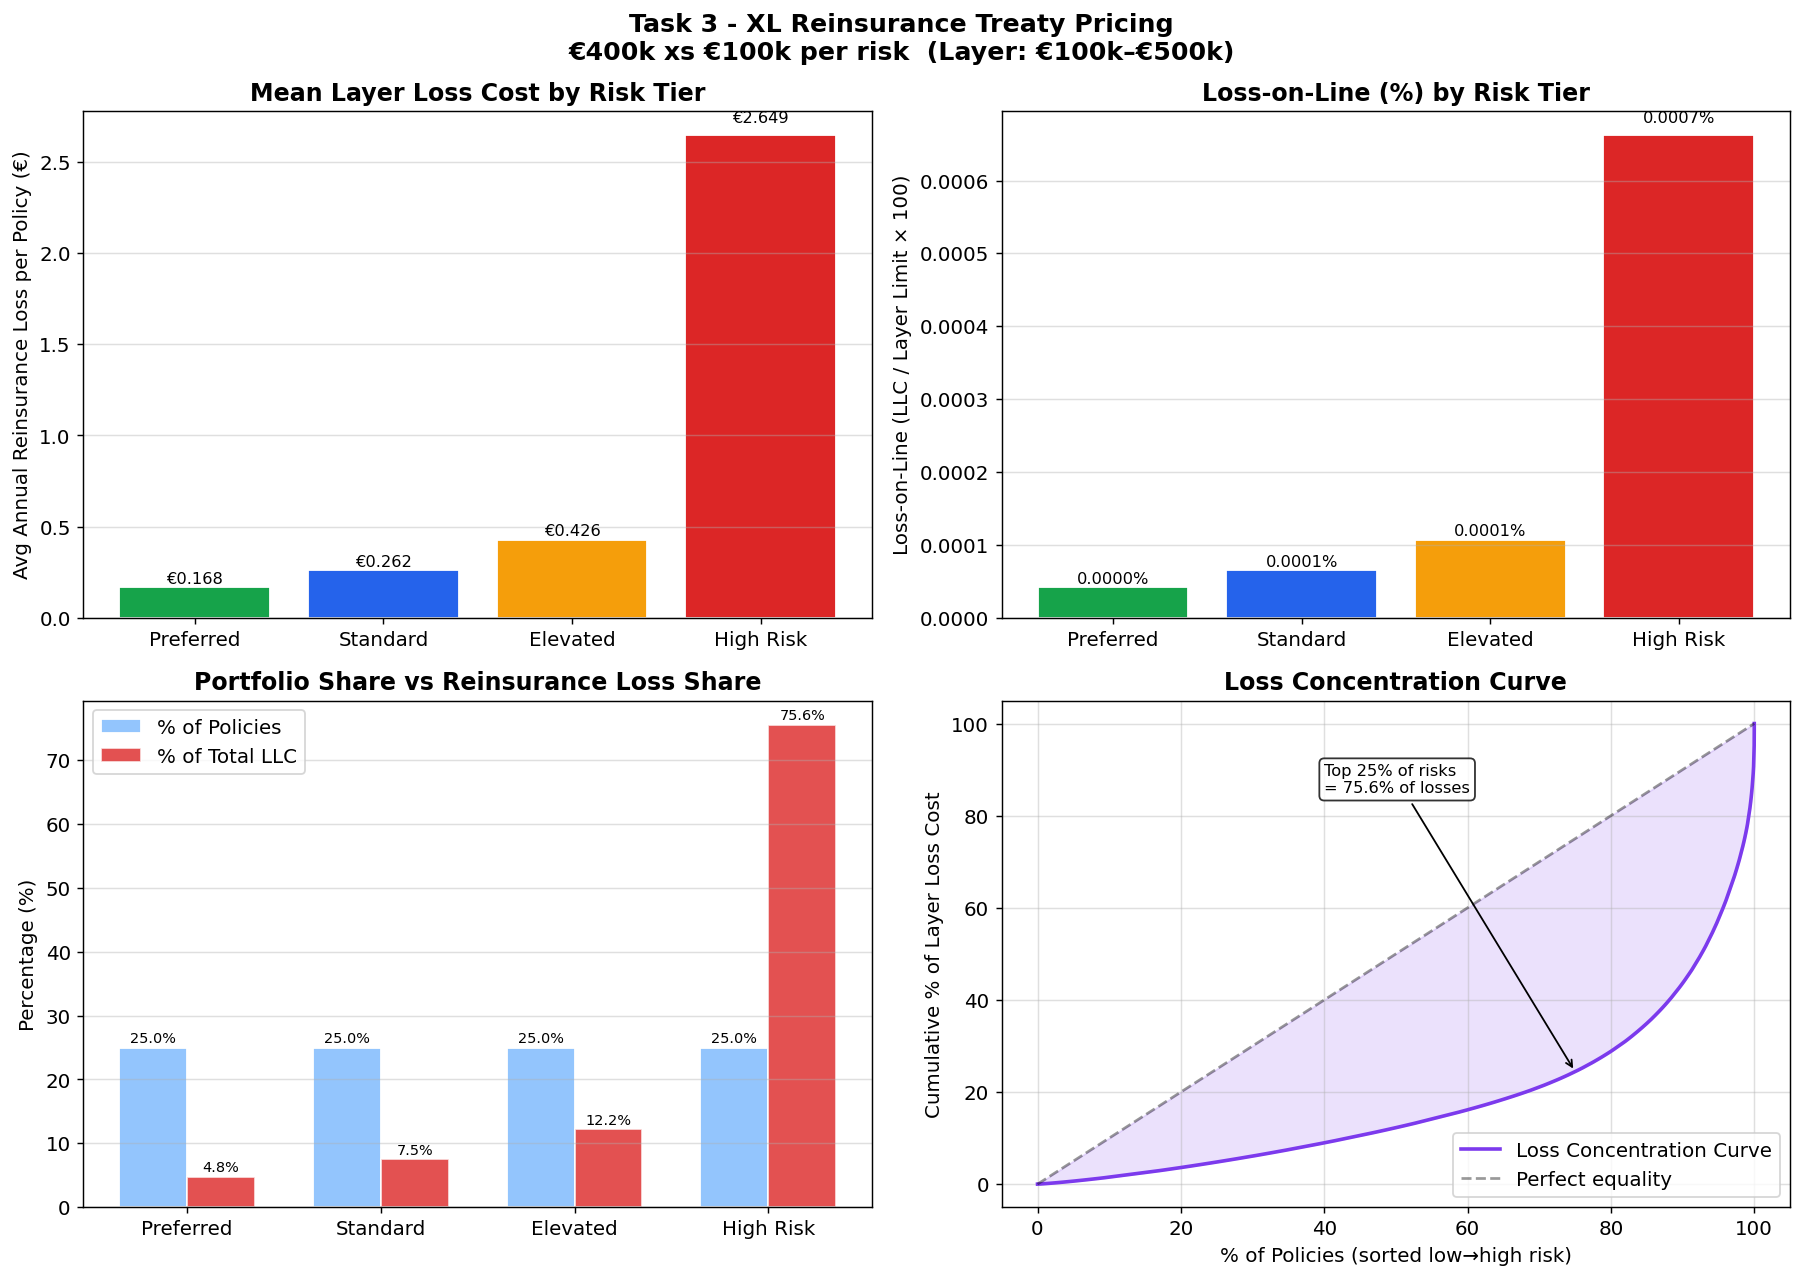

In [10]:
TIER_COLORS = {'Preferred':'#16A34A','Standard':'#2563EB',
               'Elevated':'#F59E0B','High Risk':'#DC2626'}
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Task 3 - XL Reinsurance Treaty Pricing\n€400k xs €100k per risk  (Layer: €100k–€500k)",
             fontsize=14, fontweight='bold')

# 3a. Mean LLC by tier
ax = axes[0,0]
llc_by_tier = df.groupby('RiskTier', observed=True)['LayerLossCost'].mean()
bars = ax.bar(llc_by_tier.index, llc_by_tier.values,
              color=[TIER_COLORS[t] for t in llc_by_tier.index], edgecolor='white')
ax.set_title("Mean Layer Loss Cost by Risk Tier", fontweight='bold')
ax.set_ylabel("Avg Annual Reinsurance Loss per Policy (€)")
for bar, val in zip(bars, llc_by_tier.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
            f'€{val:.3f}', ha='center', va='bottom', fontsize=9)
ax.grid(axis='y', alpha=0.4)

# 3b. Loss-on-Line by tier
ax = axes[0,1]
lol = df.groupby('RiskTier', observed=True)['LossOnLine_pct'].mean()
bars = ax.bar(lol.index, lol.values,
              color=[TIER_COLORS[t] for t in lol.index], edgecolor='white')
ax.set_title("Loss-on-Line (%) by Risk Tier", fontweight='bold')
ax.set_ylabel("Loss-on-Line (LLC / Layer Limit × 100)")
for bar, val in zip(bars, lol.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
            f'{val:.4f}%', ha='center', va='bottom', fontsize=9)
ax.grid(axis='y', alpha=0.4)

# 3c. Portfolio share vs loss share
ax = axes[1,0]
tiers = ['Preferred','Standard','Elevated','High Risk']
x, w = np.arange(4), 0.35
pct_p = [summary.loc[t,'Pct_Portfolio'] for t in tiers]
pct_l = [summary.loc[t,'Pct_TotalLLC']  for t in tiers]
bars1 = ax.bar(x-w/2, pct_p, w, label='% of Policies',  color='#93C5FD', edgecolor='white')
bars2 = ax.bar(x+w/2, pct_l, w, label='% of Total LLC', color='#DC2626', edgecolor='white', alpha=0.8)
ax.set_title("Portfolio Share vs Reinsurance Loss Share", fontweight='bold')
ax.set_ylabel("Percentage (%)")
ax.set_xticks(x); ax.set_xticklabels(tiers)
ax.legend(); ax.grid(axis='y', alpha=0.4)
for bar, val in zip(list(bars1)+list(bars2), pct_p+pct_l):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=8)

# 3d. Loss concentration curve
ax = axes[1,1]
df_s   = df.sort_values('pred_PurePremium').reset_index(drop=True)
cum_pp = np.linspace(0, 100, len(df_s))
cum_lc = df_s['LayerLossCost'].cumsum() / df_s['LayerLossCost'].sum() * 100
ax.plot(cum_pp, cum_lc, color='#7C3AED', linewidth=2, label='Loss Concentration Curve')
ax.plot([0,100],[0,100],'k--', alpha=0.4, label='Perfect equality')
ax.fill_between(cum_pp, cum_lc, cum_pp, alpha=0.15, color='#7C3AED')
idx_75 = int(0.75*len(df_s))
ax.annotate(f"Top 25% of risks\n= {100-cum_lc.iloc[idx_75]:.1f}% of losses",
            xy=(75, cum_lc.iloc[idx_75]), xytext=(40,85),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=9, bbox=dict(boxstyle='round,pad=0.3',facecolor='white',alpha=0.8))
ax.set_title("Loss Concentration Curve", fontweight='bold')
ax.set_xlabel("% of Policies (sorted low→high risk)")
ax.set_ylabel("Cumulative % of Layer Loss Cost")
ax.legend(); ax.grid(alpha=0.4)

plt.tight_layout()
plt.savefig('figures/task3_xl_pricing.png', bbox_inches='tight')
plt.show()

### XL Pricing Key Findings

- **The High Risk tier (25% of policies) drives 75.6% of total reinsurance loss cost** - this is the defining characteristic of XL treaties. The premium must reflect this concentration
- **Loss-on-Line is significantly higher for High Risk policies** - a reinsurer would price this segment very differently from Preferred
- **The Loss Concentration Curve shows a steep tail** - confirming the portfolio is typical of motor TPL: most losses are benign, but a small number of high-risk policies dominate the reinsurance exposure
- **The Loss-on-Line metric** (total Layer Loss Cost / Layer Limit) is the key output a reinsurance pricing analyst presents when quoting a treaty rate

---

## Summary

| | Result |
|---|---|
| Dataset | 668,874 French motor TPL policies |
| Claim rate | 3.73% |
| Poisson GLM Pseudo R² | 0.040 (typical for motor frequency) |
| Mean Pure Premium | €194/policy-year |
| XL Treaty Layer | €400k xs €100k |
| Total Layer Loss Cost | €586,166 |
| High Risk tier share of losses | 75.6% |

This workflow - EDA → Frequency/Severity GLM → XL treaty pricing - mirrors the core analytical process used by reinsurance pricing teams at companies.
